In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Product-Statistics-UPI-Product-statistics-upi-2016-17-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2016-17-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2017-18-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2017-18-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2018-19-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2018-19-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2019-20-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2019-20-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2020-21-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2020-21-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2021-22-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2021-22-Monthly.xlsx
Saving Product-Statistics-UPI-Product-statistics-upi-2022-23-Monthly.xlsx to Product-Statistics-UPI-Product-statistics-upi-2022-23-Month

In [3]:
files_list = sorted(glob.glob('Product-Statistics-UPI-Product-statistics-upi-*.xlsx'))
print(len(files_list))
all_years = [pd.read_excel(f, sheet_name='Product Statistics') for f in files_list]
df = pd.concat(all_years, ignore_index=True)
print(df.shape)

11
(123, 4)


In [4]:
df['value_cr'] = df['Value (In Cr.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['volume_mn'] = df['Volume (In Mn.)'].astype(str).str.strip().str.replace(',', '', regex=False).astype(float)
df['month_parsed'] = pd.to_datetime(df['Month'], format='%B-%Y')

clean_2021on = df[['month_parsed', 'volume_mn', 'value_cr']].rename(columns={'month_parsed': 'month'})
clean_2021on = clean_2021on.sort_values('month').reset_index(drop=True)
clean_2021on = clean_2021on[clean_2021on['month'] >= '2021-01-01'].reset_index(drop=True)

print("Duplicate months:", clean_2021on['month'].duplicated().sum())
print(clean_2021on.shape)

Duplicate months: 0
(66, 3)


In [5]:
ts = clean_2021on.set_index('month')['volume_mn']
ts = ts.asfreq('MS')

train = ts[:-6]
test  = ts[-6:]

print("Train range:", train.index.min(), "to", train.index.max())
print("Test range:", test.index.min(), "to", test.index.max())
print("Train size:", len(train), "months")

Train range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
Test range: 2026-01-01 00:00:00 to 2026-06-01 00:00:00
Train size: 60 months


In [6]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
fit = model.fit(disp=False)

forecast = fit.forecast(steps=6)

comparison = pd.DataFrame({'actual': test, 'forecast': forecast})
comparison['error_pct'] = ((comparison['forecast'] - comparison['actual']) / comparison['actual'] * 100).round(1)
print(comparison)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


              actual      forecast  error_pct
2026-01-01  21703.44  21778.548396        0.3
2026-02-01  20394.18  21104.596418        3.5
2026-03-01  22641.11  23128.700642        2.2
2026-04-01  22346.80  22758.673545        1.8
2026-05-01  23201.93  23543.428852        1.5
2026-06-01  22716.07  23280.679398        2.5


In [8]:
pred_in_sample = fit.predict(start=train.index[0], end=train.index[-1])
residuals = train - pred_in_sample
resid_z = (residuals - residuals.mean()) / residuals.std()

resid_z.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

print(resid_z.sort_values().head(5))   # most negative = actual came in far BELOW expected

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

month
2022-01-01   -2.937255
2025-02-01   -1.720084
2024-11-01   -1.628865
2025-10-01   -1.612101
2023-02-01   -1.138852
dtype: float64


In [9]:
pred_in_sample = fit.predict(start=train.index[0], end=train.index[-1])
residuals = train - pred_in_sample
resid_z = (residuals - residuals.mean()) / residuals.std()

resid_z.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

print(resid_z.sort_values().head(5))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

month
2022-01-01   -2.937255
2025-02-01   -1.720084
2024-11-01   -1.628865
2025-10-01   -1.612101
2023-02-01   -1.138852
dtype: float64


second run

In [10]:
# Alternative SARIMA order — simpler seasonal component (no seasonal AR, just seasonal MA)
model2 = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12))
fit2 = model2.fit(disp=False)

forecast2 = fit2.forecast(steps=6)

comparison2 = pd.DataFrame({'actual': test, 'forecast': forecast2})
comparison2['error_pct'] = ((comparison2['forecast'] - comparison2['actual']) / comparison2['actual'] * 100).round(1)
print("Model 2: (0,1,1)x(0,1,1,12)")
print(comparison2)

print("\nModel 1 avg abs error:", comparison['error_pct'].abs().mean().round(2), "%")
print("Model 2 avg abs error:", comparison2['error_pct'].abs().mean().round(2), "%")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


Model 2: (0,1,1)x(0,1,1,12)
              actual      forecast  error_pct
2026-01-01  21703.44  21785.724799        0.4
2026-02-01  20394.18  20981.845120        2.9
2026-03-01  22641.11  23075.772687        1.9
2026-04-01  22346.80  22702.988389        1.6
2026-05-01  23201.93  23478.319146        1.2
2026-06-01  22716.07  23211.958065        2.2

Model 1 avg abs error: 1.97 %
Model 2 avg abs error: 1.7 %


another thing or smth


In [11]:
# Naive seasonal baseline: forecast = same month, previous year
naive_forecast = train[-12:-6].values  # the 6 months from exactly one year before the test period

comparison_naive = pd.DataFrame({'actual': test.values, 'naive_forecast': naive_forecast}, index=test.index)
comparison_naive['error_pct'] = ((comparison_naive['naive_forecast'] - comparison_naive['actual']) / comparison_naive['actual'] * 100).round(1)

print(comparison_naive)
print("\nNaive baseline avg abs error:", comparison_naive['error_pct'].abs().mean().round(2), "%")
print("SARIMA Model 1 avg abs error:", comparison['error_pct'].abs().mean().round(2), "%")
print("SARIMA Model 2 avg abs error:", comparison2['error_pct'].abs().mean().round(2), "%")

              actual  naive_forecast  error_pct
month                                          
2026-01-01  21703.44        16996.00      -21.7
2026-02-01  20394.18        16106.19      -21.0
2026-03-01  22641.11        18301.51      -19.2
2026-04-01  22346.80        17893.42      -19.9
2026-05-01  23201.93        18677.46      -19.5
2026-06-01  22716.07        18395.01      -19.0

Naive baseline avg abs error: 20.05 %
SARIMA Model 1 avg abs error: 1.97 %
SARIMA Model 2 avg abs error: 1.7 %


In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Ljung-Box: tests if residuals still have hidden patterns the model missed
# p-value > 0.05 is good — means no significant leftover autocorrelation
lb_test = acorr_ljungbox(fit2.resid, lags=[12], return_df=True)
print("Ljung-Box test (Model 2):\n", lb_test)

# Normality check — SARIMA's confidence intervals assume roughly normal residuals
stat, p_value = stats.shapiro(fit2.resid)
print(f"\nShapiro-Wilk normality test: stat={stat:.3f}, p={p_value:.3f}")
print("(p > 0.05 suggests residuals are close to normal — good)")

Ljung-Box test (Model 2):
       lb_stat  lb_pvalue
12  12.947457   0.372871

Shapiro-Wilk normality test: stat=0.828, p=0.000
(p > 0.05 suggests residuals are close to normal — good)


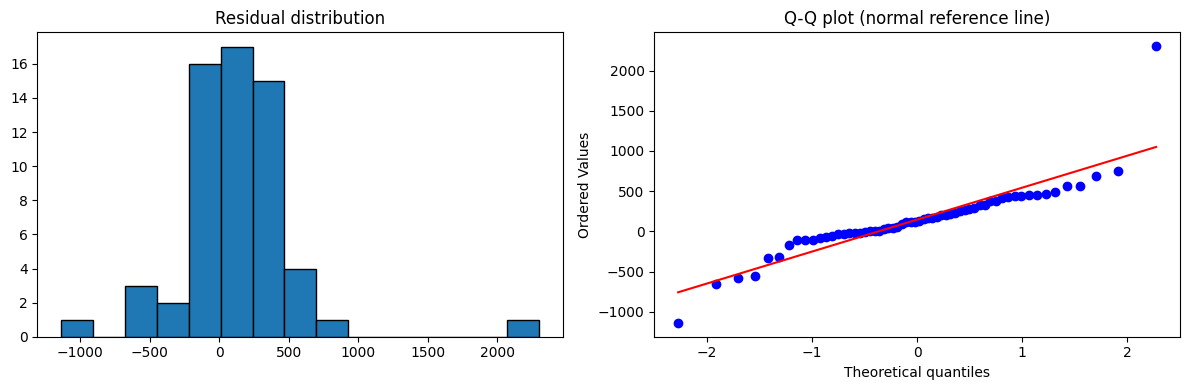

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fit2.resid, bins=15, edgecolor='black')
axes[0].set_title('Residual distribution')

stats.probplot(fit2.resid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot (normal reference line)')

plt.tight_layout()
plt.show()

In [13]:
print("Model 1 (1,1,1)x(1,1,1,12): AIC =", round(fit.aic, 1), " BIC =", round(fit.bic, 1))
print("Model 2 (0,1,1)x(0,1,1,12): AIC =", round(fit2.aic, 1), " BIC =", round(fit2.bic, 1))
print("(Lower AIC/BIC = better fit relative to model complexity)")

Model 1 (1,1,1)x(1,1,1,12): AIC = 684.0  BIC = 693.3
Model 2 (0,1,1)x(0,1,1,12): AIC = 681.0  BIC = 686.6
(Lower AIC/BIC = better fit relative to model complexity)


In [15]:
# The single extreme outlier — find its date
print(residuals.sort_values(ascending=False).head(3))
print(fit2.resid.sort_values(ascending=False).head(3))

month
2021-01-01    2302.730000
2024-10-01     784.131333
2022-05-01     683.577893
dtype: float64
month
2021-01-01    2302.730000
2024-10-01     748.514632
2022-05-01     685.221859
dtype: float64


In [16]:
# Drop the first 13 months (1 regular diff + 12 seasonal diff) — these are burn-in, not real predictions
resid_z_trimmed = resid_z.iloc[13:]

print("Duplicate months:", resid_z_trimmed.index.duplicated().sum())
print(resid_z_trimmed.shape)

# Re-check normality on the trimmed residuals
stat, p_value = stats.shapiro(resid_z_trimmed)
print(f"\nShapiro-Wilk (trimmed): stat={stat:.3f}, p={p_value:.3f}")

print("\nTop 5 stress candidates (trimmed):")
print(resid_z_trimmed.sort_values().head(5))

Duplicate months: 0
(47,)

Shapiro-Wilk (trimmed): stat=0.972, p=0.314

Top 5 stress candidates (trimmed):
month
2025-02-01   -1.720084
2024-11-01   -1.628865
2025-10-01   -1.612101
2023-02-01   -1.138852
2025-09-01   -1.133886
dtype: float64


In [17]:
resid_z_trimmed.to_csv('sarima_residuals.csv')
files.download('sarima_residuals.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>